<a href="https://colab.research.google.com/github/subrat21112006/IML_ALL/blob/main/expt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("svm")

svm


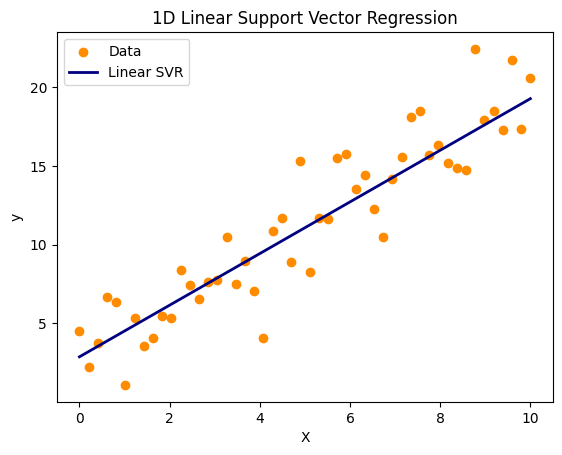

Weight (w): [[1.64162499]]
Intercept (b): [2.87343936]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# -----------------------
# Generate 1D linear data
# -----------------------
np.random.seed(0)

X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.ravel() + 1            # True linear function y = 2x + 1

# Add noise
y += np.random.normal(0, 2, size=y.shape)

# -----------------------
# Create Linear SVR model
# -----------------------
model = SVR(kernel='linear', C=100, epsilon=1.0)
model.fit(X, y)

# -----------------------
# Predict
# -----------------------
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred = model.predict(X_test)

# -----------------------
# Plot results
# -----------------------
plt.scatter(X, y, color='darkorange', label='Data')
plt.plot(X_test, y_pred, color='navy', linewidth=2, label='Linear SVR')
plt.xlabel("X")
plt.ylabel("y")
plt.title("1D Linear Support Vector Regression")
plt.legend()
plt.show()

# Print learned parameters
print("Weight (w):", model.coef_)
print("Intercept (b):", model.intercept_)

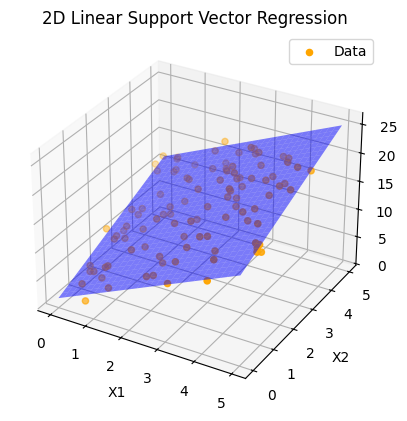

Weights: [[2.79076205 1.97264775]]
Intercept: [1.44537883]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from mpl_toolkits.mplot3d import Axes3D

# -----------------------
# Generate 2D data
# -----------------------
np.random.seed(0)

n = 100
X1 = np.random.uniform(0, 5, n)
X2 = np.random.uniform(0, 5, n)

# True function: z = 3x1 + 2x2 + 1
y = 3 * X1 + 2 * X2 + 1
y += np.random.normal(0, 2, n)   # Add noise

X = np.column_stack((X1, X2))

# -----------------------
# Train Linear SVR
# -----------------------
model = SVR(kernel='linear', C=100, epsilon=1.0)
model.fit(X, y)

# -----------------------
# Create prediction grid
# -----------------------
x1_grid, x2_grid = np.meshgrid(
    np.linspace(0, 5, 30),
    np.linspace(0, 5, 30)
)

X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(x1_grid.shape)

# -----------------------
# Plot
# -----------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.scatter(X1, X2, y, color='orange', label='Data')

# Regression plane
ax.plot_surface(x1_grid, x2_grid, y_pred, alpha=0.5, color='blue')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('2D Linear Support Vector Regression')
plt.legend()
plt.show()

# Print learned parameters
print("Weights:", model.coef_)
print("Intercept:", model.intercept_)

In [ ]:
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# -----------------------
# Generate 3D data
# -----------------------
np.random.seed(0)

n = 200
X1 = np.random.uniform(0, 5, n)
X2 = np.random.uniform(0, 5, n)
X3 = np.random.uniform(0, 5, n)

# True function
y = 2*X1 + 3*X2 - 1.5*X3 + 5
y += np.random.normal(0, 2, n)   # noise

X = np.column_stack((X1, X2, X3))

# -----------------------
# Train Linear SVR
# -----------------------
model = SVR(kernel='linear', C=100, epsilon=1.0)
model.fit(X, y)

# -----------------------
# Predictions
# -----------------------
y_pred = model.predict(X)

# -----------------------
# Evaluation
# -----------------------
print("Weights:", model.coef_)
print("Intercept:", model.intercept_)
print("R^2 score:", r2_score(y, y_pred))

Weights: [[ 1.80735845  2.98794046 -1.47840225]]
Intercept: [5.27469781]
R^2 score: 0.8758988274743266


Learned weights (w): [-6.4000e-04 -9.9968e-01]
Learned intercept (b): 2.0007466666666667
Predicted labels for [[1, 1], [2, 1], [2, 3], [3, 3]]: [ 1  1 -1 -1]


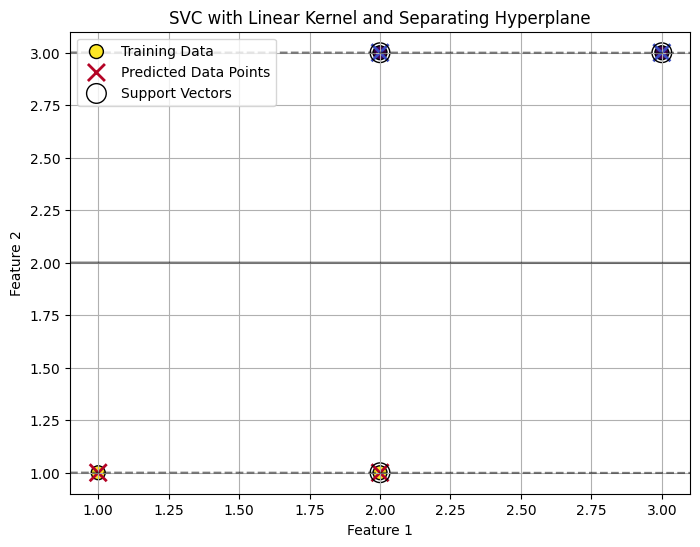

In [ ]:
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# ------------------------
# Define the dataset
# ------------------------
# Training data (first three points and their targets)
X_train = np.array([[1, 1], [2, 1], [2, 3],[3,3]])
y_train = np.array([1, 1,-1, -1])

# Data points for prediction
X_predict = np.array([[1, 1], [2, 1], [2, 3], [3, 3]])

# ------------------------
# Create and train the SVC model
# ------------------------
# Using a linear kernel for finding a hyperplane
model = SVC(kernel='linear', C=100) # C is a regularization parameter
model.fit(X_train, y_train)

# ------------------------
# Display learned parameters
# ------------------------
weights = model.coef_[0]
intercept = model.intercept_[0]
print(f"Learned weights (w): {weights}")
print(f"Learned intercept (b): {intercept}")

# ------------------------
# Predict labels for the specified data points
# ------------------------
predicted_labels = model.predict(X_predict)
print(f"Predicted labels for {X_predict.tolist()}: {predicted_labels}")

# ------------------------
# Visualize the separating hyperplane (optional, but good for understanding)
# ------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=100, edgecolors='k', label='Training Data')
plt.scatter(X_predict[:, 0], X_predict[:, 1], c=predicted_labels, cmap='coolwarm', marker='x', s=150, linewidth=2, label='Predicted Data Points')

# Plot the separating hyperplane
ax = plt.gca()
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(x_lim[0], x_lim[1], 30)
yy = np.linspace(y_lim[0], y_lim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
# Plot support vectors
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='k', label='Support Vectors')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVC with Linear Kernel and Separating Hyperplane')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Given values
alphas = np.array([1, 1, 1])
support_vectors = np.array([
    [0, -1, 1],  # x1
    [0, 2, -1],   # x2
    [-1, 0, 2]    # x3
])
target_outputs = np.array([1, -1, -1]) # y1, y2, y3

# ----------------------------------------
# Calculate the weight vector (w)
# w = sum(alpha_i * y_i * x_i) for all support vectors
# ----------------------------------------
w = np.sum(alphas.reshape(-1, 1) * target_outputs.reshape(-1, 1) * support_vectors, axis=0)

print(f"Calculated weight vector (w): {w}")

# ----------------------------------------
# Calculate the bias (b) for each support vector
# For a support vector (x_s, y_s), y_s * (w . x_s + b) = 1
# This implies b = (1 / y_s) - (w . x_s)
# ----------------------------------------

b_values = []
for i in range(len(support_vectors)):
    x_s = support_vectors[i]
    y_s = target_outputs[i]

    w_dot_x_s = np.dot(w, x_s)
    b = (1 / y_s) - w_dot_x_s
    b_values.append(b)
    print(f"Bias (b) calculated using support vector {x_s} (target {y_s}): {b:.4f}")

print(f"\nAll calculated b values: {b_values}")

# ----------------------------------------
# Check for consistency and explain
# ----------------------------------------
if len(set(np.round(b_values, 4))) == 1:
    print("\nThe calculated bias (b) values are consistent.")
    print(f"The separating hyperplane equation is: {w[0]:.2f}*x1 + {w[1]:.2f}*x2 + {w[2]:.2f}*x3 + {b_values[0]:.2f} = 0")
else:
    print("\n*** Inconsistency Detected ***")
    print("The calculated bias (b) values are inconsistent across the provided support vectors. ")
    print("In a valid linear SVM where all given points are support vectors on the margin (alpha > 0 and y_i * (w.x_i + b) = 1), ")
    print("the bias 'b' should be consistent when calculated from each support vector. This suggests that the hypothetical ")
    print("dataset and parameters provided may not represent a perfectly consistent standard linear SVM solution.")
    print("\nIf we were to pick one, using the first support vector, the hyperplane would be approximately:")
    print(f"  {w[0]:.2f}*x1 + {w[1]:.2f}*x2 + {w[2]:.2f}*x3 + {b_values[0]:.2f} = 0")

Calculated weight vector (w): [ 1 -3  0]
Bias (b) calculated using support vector [ 0 -1  1] (target 1): -2.0000
Bias (b) calculated using support vector [ 0  2 -1] (target -1): 5.0000
Bias (b) calculated using support vector [-1  0  2] (target -1): 0.0000

All calculated b values: [np.float64(-2.0), np.float64(5.0), np.float64(0.0)]

*** Inconsistency Detected ***
The calculated bias (b) values are inconsistent across the provided support vectors. 
In a valid linear SVM where all given points are support vectors on the margin (alpha > 0 and y_i * (w.x_i + b) = 1), 
the bias 'b' should be consistent when calculated from each support vector. This suggests that the hypothetical 
dataset and parameters provided may not represent a perfectly consistent standard linear SVM solution.

If we were to pick one, using the first support vector, the hyperplane would be approximately:
  1.00*x1 + -3.00*x2 + 0.00*x3 + -2.00 = 0


In [ ]:
import numpy as np

# Learned parameters from the previous step (using the first b for consistency)
w = np.array([1, -3, 0])
b = np.float64(-2.00)

# New input feature
X_new = np.array([0.2, 0.8, 0.4])

# Calculate the decision function: w . X_new + b
decision_value = np.dot(w, X_new) + b

# Predict the label based on the sign of the decision value
predicted_label = np.sign(decision_value)

print(f"Input feature: {X_new}")
print(f"Decision value (w.X + b): {decision_value:.4f}")
print(f"Predicted label: {int(predicted_label)}")


Input feature: [0.2 0.8 0.4]
Decision value (w.X + b): -4.2000
Predicted label: -1


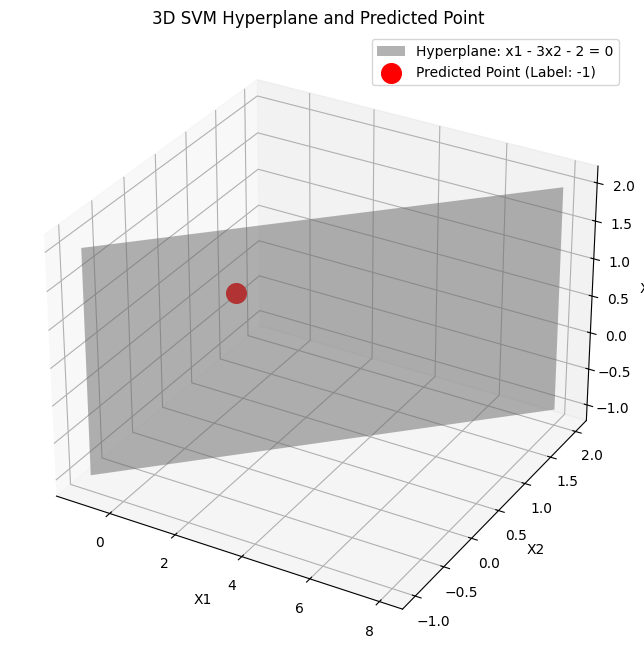

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Learned parameters
w = np.array([1, -3, 0])
b = np.float64(-2.00)

# New input feature and its predicted label
X_new = np.array([0.2, 0.8, 0.4])
predicted_label = np.sign(np.dot(w, X_new) + b)

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the separating hyperplane: w[0]*x1 + w[1]*x2 + w[2]*x3 + b = 0
# In our case: 1*x1 - 3*x2 + 0*x3 - 2 = 0  => x1 = 3*x2 + 2

x2_surf = np.linspace(-1, 2, 50) # Choose a range that makes sense for visualization
x3_surf = np.linspace(-1, 2, 50)
X2_surf, X3_surf = np.meshgrid(x2_surf, x3_surf)
X1_surf = 3 * X2_surf + 2 # Calculate x1 based on the hyperplane equation

ax.plot_surface(X1_surf, X2_surf, X3_surf, alpha=0.5, rstride=100, cstride=100, color='gray', label='Hyperplane: x1 - 3x2 - 2 = 0')

# Plot the predicted point
ax.scatter(X_new[0], X_new[1], X_new[2], color='red', marker='o', s=200, label=f'Predicted Point (Label: {int(predicted_label)})')

# Set labels and title
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('3D SVM Hyperplane and Predicted Point')
ax.legend()

plt.show()

Calculated weight vector (w): [ 2 -1 -2]
Using bias (b): 0.0
Input feature: [ 0.5  1.  -0.5]
Decision value (w.X + b): 1.0000
Predicted label: 1


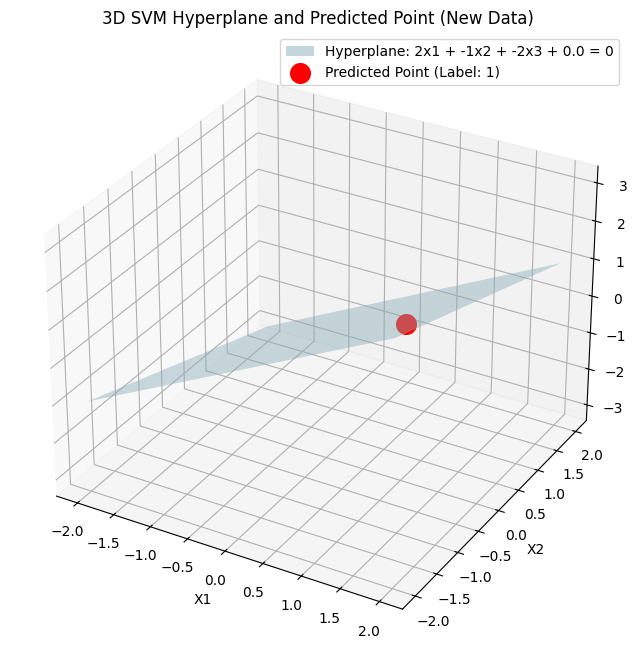

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Given values
alphas_new = np.array([1, 1, 1])
support_vectors_new = np.array([
    [1, 0, -1],
    [-1, 2, 2],
    [0, -1, -1]
])
target_outputs_new = np.array([1, -1, -1])

# Calculate the weight vector (w)
w_new = np.sum(alphas_new.reshape(-1, 1) * target_outputs_new.reshape(-1, 1) * support_vectors_new, axis=0)

# User specified b = 0
b_new = 0.0

# New input feature
X_new_point = np.array([0.5, 1, -0.5])

# Calculate the decision function: w . X_new + b
decision_value_new = np.dot(w_new, X_new_point) + b_new

# Predict the label based on the sign of the decision value
predicted_label_new = np.sign(decision_value_new)

print(f"Calculated weight vector (w): {w_new}")
print(f"Using bias (b): {b_new}")
print(f"Input feature: {X_new_point}")
print(f"Decision value (w.X + b): {decision_value_new:.4f}")
print(f"Predicted label: {int(predicted_label_new)}")

# ----------------------------------------
# Visualize the hyperplane and predicted point
# ----------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the separating hyperplane: w_new[0]*x1 + w_new[1]*x2 + w_new[2]*x3 + b_new = 0
# The equation is: x1 - 3*x2 - 2*x3 + 0 = 0 (based on calculated w_new and b_new)

# Create a meshgrid for two of the features and solve for the third
x1_surf = np.linspace(-2, 2, 50)
x2_surf = np.linspace(-2, 2, 50)
X1_surf, X2_surf = np.meshgrid(x1_surf, x2_surf)

# Handle cases where a weight is zero to avoid division by zero or incorrect plane representation
if w_new[2] != 0:
    X3_surf = (-w_new[0] * X1_surf - w_new[1] * X2_surf - b_new) / w_new[2]
    ax.plot_surface(X1_surf, X2_surf, X3_surf, alpha=0.5, color='lightblue', label=f'Hyperplane: {w_new[0]}x1 + {w_new[1]}x2 + {w_new[2]}x3 + {b_new} = 0')
elif w_new[1] != 0:
    X3_surf = np.zeros_like(X1_surf) # x3 can be any value, project onto x1-x2 plane
    X2_surf = (-w_new[0] * X1_surf - b_new) / w_new[1]
    ax.plot_surface(X1_surf, X2_surf, X3_surf, alpha=0.5, color='lightblue', label=f'Hyperplane: {w_new[0]}x1 + {w_new[1]}x2 + {b_new} = 0')
elif w_new[0] != 0:
    X3_surf = np.zeros_like(X1_surf) # x3 can be any value
    X1_surf = (-w_new[1] * X2_surf - b_new) / w_new[0]
    ax.plot_surface(X1_surf, X2_surf, X3_surf, alpha=0.5, color='lightblue', label=f'Hyperplane: {w_new[0]}x1 + {b_new} = 0')
else:
    print("Warning: All weights are zero, cannot define a hyperplane.")


# Plot the predicted point
ax.scatter(X_new_point[0], X_new_point[1], X_new_point[2], color='red', marker='o', s=200, label=f'Predicted Point (Label: {int(predicted_label_new)})')

# Set labels and title
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('3D SVM Hyperplane and Predicted Point (New Data)')
ax.legend()

plt.show()